In [15]:
import duckdb
import pandas as pd

con = duckdb.connect(r"C:\Users\jrf24\Incendios-Forestales-\data\BaseDeDatos_Working.db")

tiempo = con.execute("SELECT * FROM olap.vw_cubo_tiempo").df()
geo = con.execute("SELECT * FROM olap.vw_cubo_geografico").df()
clima = con.execute("SELECT * FROM olap.vw_clima_riesgo").df()
impacto = con.execute("SELECT * FROM olap.vw_impacto_poblacion").df()

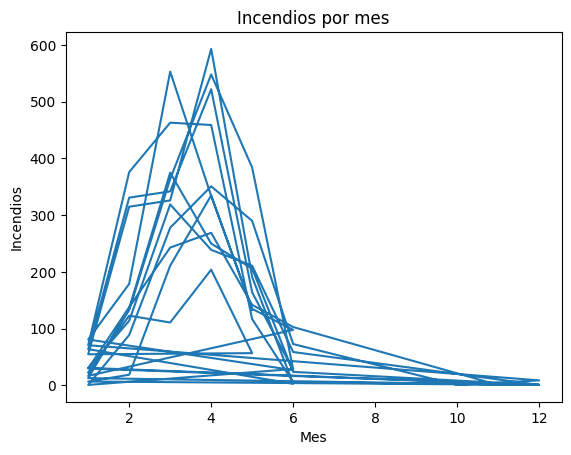

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(tiempo["mes"], tiempo["incendios"])
plt.title("Incendios por mes")
plt.xlabel("Mes")
plt.ylabel("Incendios")
plt.show()

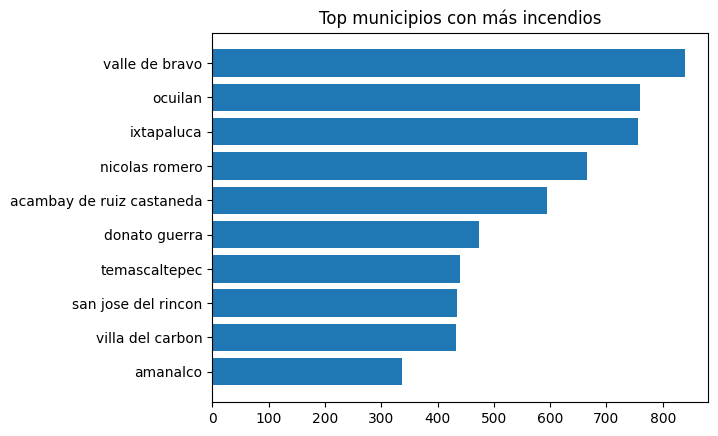

In [17]:
top_geo = geo.sort_values("incendios", ascending=False).head(10)

plt.figure()
plt.barh(top_geo["municipio"], top_geo["incendios"])
plt.title("Top municipios con más incendios")
plt.gca().invert_yaxis()
plt.show()

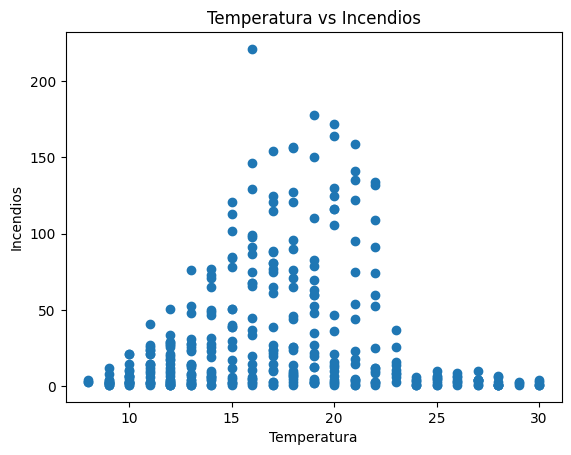

In [18]:
plt.figure()
plt.scatter(clima["temp"], clima["incendios"])
plt.title("Temperatura vs Incendios")
plt.xlabel("Temperatura")
plt.ylabel("Incendios")
plt.show()

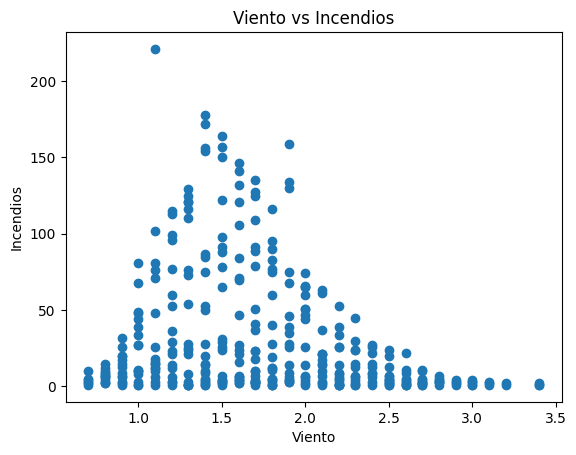

In [19]:
plt.figure()
plt.scatter(clima["viento"], clima["incendios"])
plt.title("Viento vs Incendios")
plt.xlabel("Viento")
plt.ylabel("Incendios")
plt.show()

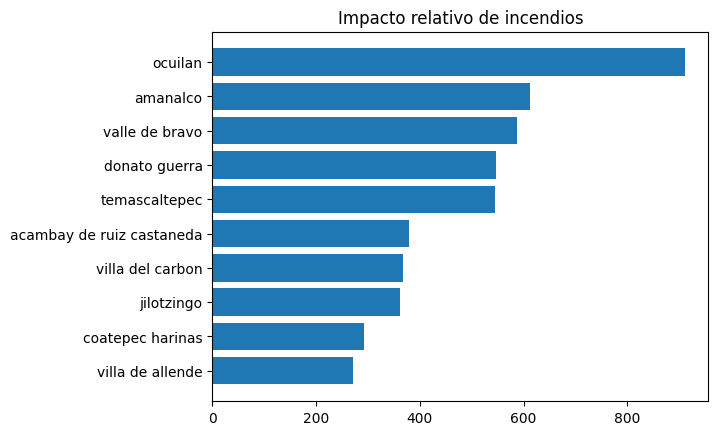

In [20]:
impacto_filtrado = impacto[impacto["poblacion"] > 10000]

top_imp = impacto_filtrado.sort_values("impacto", ascending=False).head(10)

plt.figure()
plt.barh(top_imp["municipio"], top_imp["impacto"])
plt.title("Impacto relativo de incendios")
plt.gca().invert_yaxis()
plt.show()